In [1]:
import pandas, numpy, sklearn.linear_model, sklearn.preprocessing, sklearn.model_selection, seaborn, matplotlib.pyplot

In [2]:
dataframe = pandas.read_csv("data/mobile_devices.csv", sep=";")
dataframe

,IDIndikator,skrIndikator,nVrUredjaja,nTer,God+Mes,nVrTacka,Vrednost,IDStatusPodatka,nStatusPodatka,IDStatusPoverljivosti,nStatusPoverljivosti,IDJedinicaMere,nJedinicaMere
0,270101IND01,Uređaji zastupljeni u domaćinstvima,TV,REPUBLIKA SRBIJA,200600,2006,95.7,A,Konačan podatak,F,Slobodan za objavlјivanje,PC,%
1,270101IND01,Uređaji zastupljeni u domaćinstvima,TV,REPUBLIKA SRBIJA,200700,2007,97.8,A,Konačan podatak,F,Slobodan za objavlјivanje,PC,%
2,270101IND01,Uređaji zastupljeni u domaćinstvima,TV,REPUBLIKA SRBIJA,200800,2008,98.4,A,Konačan podatak,F,Slobodan za objavlјivanje,PC,%
3,270101IND01,Uređaji zastupljeni u domaćinstvima,TV,REPUBLIKA SRBIJA,200900,2009,98.6,A,Konačan podatak,F,Slobodan za objavlјivanje,PC,%
4,270101IND01,Uređaji zastupljeni u domaćinstvima,TV,REPUBLIKA SRBIJA,201000,2010,98.7,A,Konačan podatak,F,Slobodan za objavlјivanje,PC,%
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,270101IND01,Uređaji zastupljeni u domaćinstvima,Laptop,REPUBLIKA SRBIJA,202100,2021,53.9,A,Konačan podatak,F,Slobodan za objavlјivanje,PC,%
96,270101IND01,Uređaji zastupljeni u domaćinstvima,Laptop,REPUBLIKA SRBIJA,202200,2022,56.1,A,Konačan podatak,F,Slobodan za objavlјivanje,PC,%
97,270101IND01,Uređaji zastupljeni u domaćinstvima,Laptop,REPUBLIKA SRBIJA,202300,2023,55.0,A,Konačan podatak,F,Slobodan za objavlјivanje,PC,%
98,270101IND01,Uređaji zastupljeni u domaćinstvima,Laptop,REPUBLIKA SRBIJA,202400,2024,53.9,A,Konačan podatak,F,Slobodan za objavlјivanje,PC,%


In [3]:
dataframe = dataframe.loc[dataframe[dataframe.columns[2]] == "Mobilni telefon"]
dataframe

,IDIndikator,skrIndikator,nVrUredjaja,nTer,God+Mes,nVrTacka,Vrednost,IDStatusPodatka,nStatusPodatka,IDStatusPoverljivosti,nStatusPoverljivosti,IDJedinicaMere,nJedinicaMere
20,270101IND01,Uređaji zastupljeni u domaćinstvima,Mobilni telefon,REPUBLIKA SRBIJA,200600,2006,71.2,A,Konačan podatak,F,Slobodan za objavlјivanje,PC,%
21,270101IND01,Uređaji zastupljeni u domaćinstvima,Mobilni telefon,REPUBLIKA SRBIJA,200700,2007,73.6,A,Konačan podatak,F,Slobodan za objavlјivanje,PC,%
22,270101IND01,Uređaji zastupljeni u domaćinstvima,Mobilni telefon,REPUBLIKA SRBIJA,200800,2008,74.5,A,Konačan podatak,F,Slobodan za objavlјivanje,PC,%
23,270101IND01,Uređaji zastupljeni u domaćinstvima,Mobilni telefon,REPUBLIKA SRBIJA,200900,2009,80.1,A,Konačan podatak,F,Slobodan za objavlјivanje,PC,%
24,270101IND01,Uređaji zastupljeni u domaćinstvima,Mobilni telefon,REPUBLIKA SRBIJA,201000,2010,82.0,A,Konačan podatak,F,Slobodan za objavlјivanje,PC,%
25,270101IND01,Uređaji zastupljeni u domaćinstvima,Mobilni telefon,REPUBLIKA SRBIJA,201100,2011,82.5,A,Konačan podatak,F,Slobodan za objavlјivanje,PC,%
26,270101IND01,Uređaji zastupljeni u domaćinstvima,Mobilni telefon,REPUBLIKA SRBIJA,201200,2012,83.9,A,Konačan podatak,F,Slobodan za objavlјivanje,PC,%
27,270101IND01,Uređaji zastupljeni u domaćinstvima,Mobilni telefon,REPUBLIKA SRBIJA,201300,2013,86.9,A,Konačan podatak,F,Slobodan za objavlјivanje,PC,%
28,270101IND01,Uređaji zastupljeni u domaćinstvima,Mobilni telefon,REPUBLIKA SRBIJA,201400,2014,90.6,A,Konačan podatak,F,Slobodan za objavlјivanje,PC,%
29,270101IND01,Uređaji zastupljeni u domaćinstvima,Mobilni telefon,REPUBLIKA SRBIJA,201500,2015,90.3,A,Konačan podatak,F,Slobodan za objavlјivanje,PC,%


In [4]:
train_dataframe = dataframe[["nVrTacka", "Vrednost"]]
train_dataframe

,nVrTacka,Vrednost
20,2006,71.2
21,2007,73.6
22,2008,74.5
23,2009,80.1
24,2010,82.0
25,2011,82.5
26,2012,83.9
27,2013,86.9
28,2014,90.6
29,2015,90.3


In [5]:
train_dataframe.dtypes

nVrTacka    int64
Vrednost      str
dtype: object

In [6]:
train_dataframe["Vrednost"] = train_dataframe["Vrednost"].astype(numpy.float64)
train_dataframe["nVrTacka"] = train_dataframe["nVrTacka"].astype(numpy.int64)
train_dataframe.dtypes

nVrTacka      int64
Vrednost    float64
dtype: object

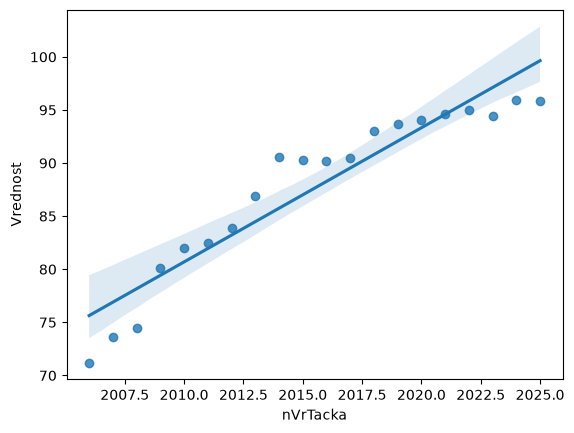

In [7]:
seaborn.regplot(data=train_dataframe, x="nVrTacka", y="Vrednost")
matplotlib.pyplot.show()

In [8]:
scaler = sklearn.preprocessing.StandardScaler()
scaler

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [9]:
normalized_data = scaler.fit_transform(train_dataframe[["Vrednost"]])
normalized_data

array([[-2.13080328],
       [-1.81973711],
       [-1.70308729],
       [-0.97726622],
       [-0.7310055 ],
       [-0.66620005],
       [-0.48474478],
       [-0.09591207],
       [ 0.38364828],
       [ 0.34476501],
       [ 0.33180392],
       [ 0.37068719],
       [ 0.69471445],
       [ 0.78544208],
       [ 0.83728645],
       [ 0.9020919 ],
       [ 0.95393626],
       [ 0.87616972],
       [ 1.07058607],
       [ 1.05762498]])

In [10]:
train_dataframe["Vrednost"] = normalized_data
train_dataframe

,nVrTacka,Vrednost
20,2006,-2.130803
21,2007,-1.819737
22,2008,-1.703087
23,2009,-0.977266
24,2010,-0.731006
25,2011,-0.666200
26,2012,-0.484745
27,2013,-0.095912
28,2014,0.383648
29,2015,0.344765


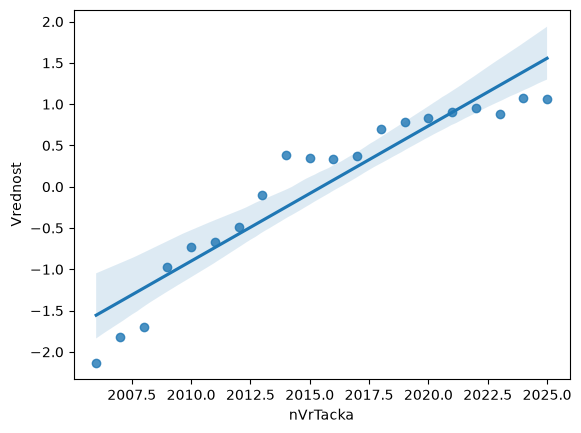

In [11]:
seaborn.regplot(data=train_dataframe, x="nVrTacka", y="Vrednost")
matplotlib.pyplot.show()

In [12]:
X = train_dataframe[["nVrTacka"]]
Y = train_dataframe["Vrednost"]

In [13]:
x_train, x_test, y_train, y_test = sklearn.model_selection.train_test_split(X, Y, test_size=0.25)

In [14]:
model = sklearn.linear_model.LinearRegression()
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.16]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['nVrTacka']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-315.2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [16]:
model.score(x_test, y_test)

0.8578970982472947